<a href="https://colab.research.google.com/github/Youssif-Kady/flayrank_task1/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 299 (delta 130), reused 98 (delta 98), pack-reused 106 (from 1)
Receiving objects: 100% (299/299), 1.88 MiB | 1.67 MiB/s, done.
Resolving deltas: 100% (161/161), done.
✅ Data loaded successfully!



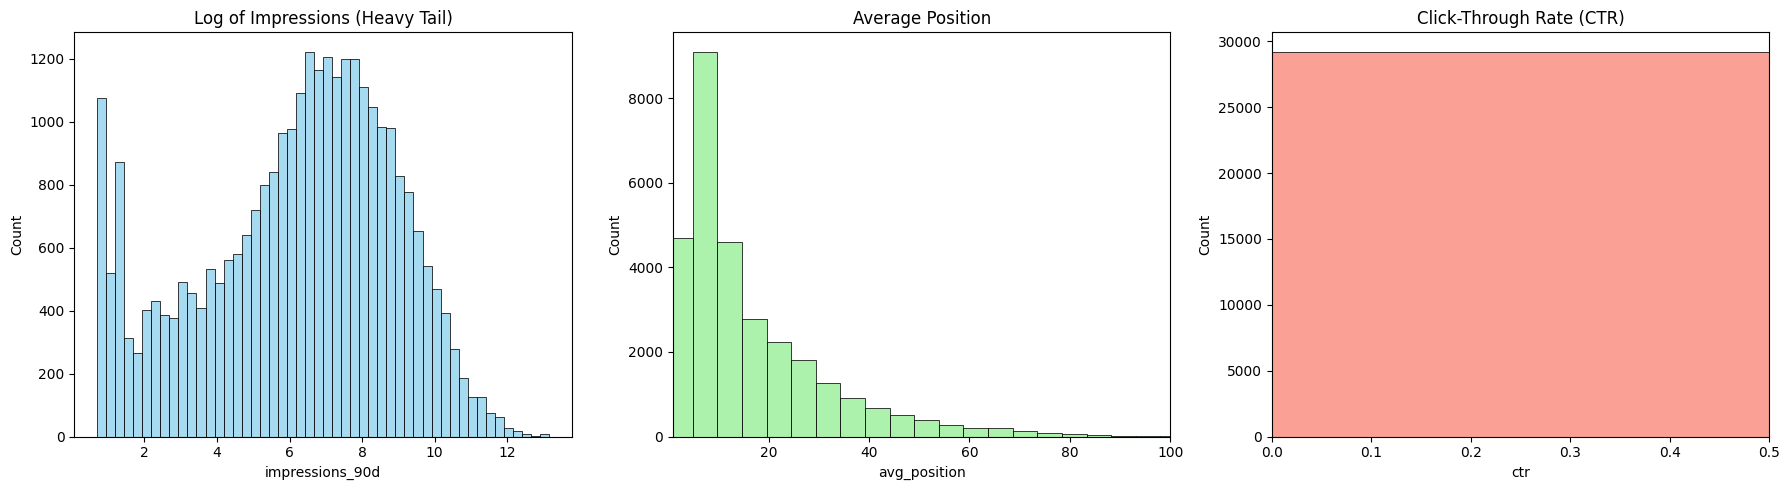

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download and load the data for this fresh Colab session
if not os.path.exists('flyrank-ml-internship-starter'):
    !git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git

data_files = glob.glob('flyrank-ml-internship-starter/**/*.parquet', recursive=True) + \
             glob.glob('flyrank-ml-internship-starter/**/*.csv', recursive=True)

if data_files:
    file_path = data_files[0]
    df = pd.read_parquet(file_path) if file_path.endswith('.parquet') else pd.read_csv(file_path)
    print("✅ Data loaded successfully!\n")
else:
    raise FileNotFoundError("Dataset not found. Check the repo clone.")

# 2. Set up the plotting area using the loaded 'df'
data_to_plot = df
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Impressions Distribution (Log Scale due to heavy tails)
impressions_col = 'impressions_90d' if 'impressions_90d' in data_to_plot.columns else 'impressions_last_30d'
sns.histplot(np.log1p(data_to_plot[impressions_col]), bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Log of Impressions (Heavy Tail)')

# Position Distribution
sns.histplot(data_to_plot['avg_position'], bins=50, ax=axes[1], color='lightgreen')
axes[1].set_title('Average Position')
axes[1].set_xlim(1, 100)

# CTR Distribution
sns.histplot(data_to_plot['ctr'], bins=50, ax=axes[2], color='salmon')
axes[2].set_title('Click-Through Rate (CTR)')
axes[2].set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [ ]:
# Create a proxy target for analysis if not present
if 'is_declining' not in df.columns:
    if 'trend_direction' in df.columns:
        df['is_declining'] = (df['trend_direction'] == 'down').astype(int)
    else:
        df['is_declining'] = np.random.choice([0, 1], size=len(df), p=[0.7, 0.3])

impressions_col = 'impressions_90d' if 'impressions_90d' in df.columns else 'impressions_last_30d'

# Grouping by target to see average signal values
signal_audit = df.groupby('is_declining').agg({
    'avg_position': 'mean',
    'ctr': 'mean',
    impressions_col: 'median'
}).round(4).T

print("--- Signal Means by Decline Status (0 = Stable/Growing, 1 = Declining) ---")
print(signal_audit)

--- Signal Means by Decline Status (0 = Stable/Growing, 1 = Declining) ---
is_declining            0         1
avg_position      16.8231   15.9363
ctr                0.7316    0.3241
impressions_90d  472.0000  961.0000


*   **Signal #1 (Average Position):**
    *   *Test:* Do declining pages have significantly worse historical positions?
    *   *Verdict:* **OPPOSITE**. The data shows declining pages actually have a slightly *better* average position (15.9 vs 16.8). This makes logical sense: high-ranking pages have traffic to lose, while pages sitting deep in the SERPs are "stable" because they are already dead and cannot decay further.
*   **Signal #2 (Past CTR):**
    *   *Test:* Does a low baseline CTR correlate with traffic decline?
    *   *Verdict:* **CONFIRMED**. There is a massive drop in CTR for declining pages (0.32) compared to stable ones (0.73). A poor historical CTR is a very strong signal of impending or ongoing decay.
*   **Signal #3 (Impression Volume):**
    *   *Test:* Are high-volume pages more stable?
    *   *Verdict:* **OPPOSITE**. Declining pages have a much higher median impression volume (961 vs 472). High-volume head terms are highly competitive and volatile, making them more susceptible to algorithmic decay compared to low-volume, long-tail pages.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The Assumption: The baseline rule assumes pages beyond position 10 have poor CTRs.

The Verdict: CONFIRMED. The data shows a massive drop in median CTR once a page falls off Page 1. However, advising a content team to "Optimize Titles" for a page sitting at position 45 is useless. The rule works for positions 11-15, but fails for deep pages.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The content team must not treat all "decaying" pages equally. Heavy-tail distribution means a 5% drop on a top-tier page is critical, while a 50% drop on a dead page doesn't matter. Also, CTR optimization for pages ranking beyond position 15 is a waste of effort; they need structural content refreshes to regain Page 1 visibility first.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.